# Mini Project 2: House Price Prediction Model

## Objective

Build a Linear Regression model to predict house prices using property
features such as area, bedrooms, bathrooms, stories, parking, and other
housing characteristics.

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-learn

## Tasks

- Load and explore the housing dataset
- Check for missing values
- Separate features and target
- Encode categorical features using One-Hot Encoding
- Split the dataset into training and testing sets
- Train a Linear Regression model
- Predict house prices
- Evaluate the model using R², MAE, MSE, and RMSE
- Visualize actual vs predicted prices

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv("Housing.csv")

data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [4]:
data.shape

(545, 13)

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 69.2 KB


In [6]:
data.isnull().sum().sort_values(ascending=False).head(20)

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [7]:
X = data.drop("price", axis=1)
y = data["price"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (545, 12)
Target shape: (545,)


In [8]:
categorical_cols = X.select_dtypes(include="object").columns

print("Categorical columns:")
print(categorical_cols)

Categorical columns:
Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='str')


C:\Users\pc\AppData\Local\Temp\ipykernel_13112\3459500389.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include="object").columns


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=47
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (436, 12)
Testing data: (109, 12)


In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

ct = ColumnTransformer(
    transformers=[
        ("encoder", OneHotEncoder(
            drop="first",
            handle_unknown="ignore"
        ), categorical_cols)
    ],
    remainder="passthrough"
)

X_train_encoded = ct.fit_transform(X_train)
X_test_encoded = ct.transform(X_test)

print("Encoded X_train shape:", X_train_encoded.shape)
print("Encoded X_test shape:", X_test_encoded.shape)

Encoded X_train shape: (436, 13)
Encoded X_test shape: (109, 13)


In [16]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train_encoded, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[332239.54,386804.51,348456.27,...,864613.39,517841.75,301737.13]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3.383e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(13)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](13,)","[43316.61, 20.5 , 16.9 ,..., 6.35, 6.12, 4.17]"


In [17]:
y_pred = model.predict(X_test_encoded)

print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
[3635129.2739923  3309260.36400804 9096726.41565376 4675574.71449284
 4571535.76990796 3038981.58189833 2245243.7737394  7832148.84340459
 3164649.45819703 4530771.22314959]


In [18]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print(f"R² Score: {r2:.3f}")

R² Score: 0.736


In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.3f}")

MAE: 771524.77
MSE: 1107705593159.57
RMSE: 1052475.93
R² Score: 0.736


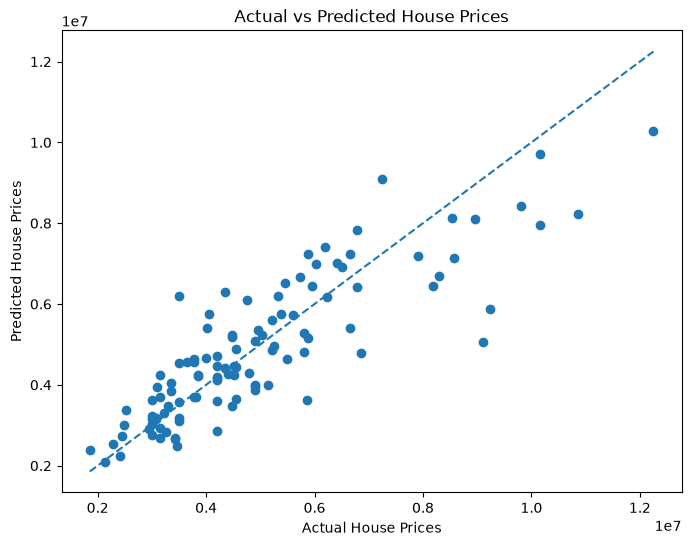

In [20]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices")

plt.show()

In [21]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
0,3003000,3.635129e+06
1,3220000,3.309260e+06
2,7245000,9.096726e+06
3,3990000,4.675575e+06
4,3640000,4.571536e+06
5,3010000,3.038982e+06
6,2408000,2.245244e+06
7,6790000,7.832149e+06
8,3080000,3.164649e+06
9,3500000,4.530771e+06


## Conclusion

A Linear Regression model was successfully developed to predict house prices
using the Housing dataset.

The categorical features were converted into numerical features using
One-Hot Encoding, while the numerical features were retained. The dataset
was divided into training and testing sets, and the model was trained on the
training data.

The model achieved an R² score of 0.736 on the test dataset, indicating that
the model explains approximately 73.6% of the variation in house prices.

The Actual vs Predicted plot was also used to visually evaluate the model's
predictions. Overall, the project demonstrates how Linear Regression can be
used for house price prediction.